# Laboratory Day 2: Digital Image

## 1. Image operations by OpenCV
In this section, we will learn basic OpenCV operations for images. OpenCV is an open-source library for the computer vision. It provides a tool to work with images. It was officially launched in 1999 by Intel and was written in C/C++ in the early stage. But now it is commonly used in Python for the computer vision as well.

Reference:
https://docs.opencv.org/4.x/d0/de3/tutorial_py_intro.html

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# please do not use other library to solve the exercises in this laboratory.

**Exercise 1.1 (5 points)**:
- Load color image file 'dog_color.jpg' using i_c = cv2.imread(..). Note that OpenCV outputs BRG channels, not RGB channels.
- Convert BRG to RGB channels. And then display the image using plt.imshow().
- Select only the red channel and display it using plt.imshow().


In [3]:
!git clone https://github.com/Ambos14/ComputerVision26.git

Cloning into 'ComputerVision26'...
remote: Enumerating objects: 29, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 29 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (29/29), 2.86 MiB | 7.59 MiB/s, done.
Resolving deltas: 100% (4/4), done.


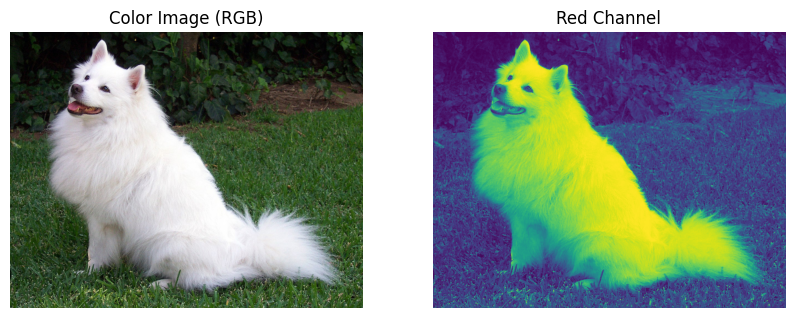

In [6]:
# Solution
# The file 'Praktikum 1/dog_color.jpg' was not found.
# Please ensure the image file is uploaded to your Colab environment and the path is correct.
# Also, for loading images with OpenCV, cv2.imread() should be used.

# Corrected code structure:
# i_c = cv2.imread('path/to/your/dog_color.jpg')
# For example, if the file is in the root directory, use 'dog_color.jpg'
# If it's in a subfolder called 'images', use 'images/dog_color.jpg'

# Assuming 'dog_color.jpg' is directly in the content directory after uploading:
i_c = cv2.imread('/content/ComputerVision26/Praktikum 1/dog_color.jpg')

# Check if the image was loaded successfully
if i_c is None:
    print("Error: Could not load image. Please check the file path.")
else:
    # Convert BRG to RGB channels (OpenCV loads in BGR by default)
    i_c_rgb = cv2.cvtColor(i_c, cv2.COLOR_BGR2RGB)

    # Display the RGB image
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(i_c_rgb)
    plt.title('Color Image (RGB)')
    plt.axis('off')

    # Select only the red channel
    red_channel = i_c_rgb[:, :, 0] # Red channel is the first channel in RGB

    # Display the red channel
    plt.subplot(1, 2, 2)
    plt.imshow(red_channel)
    plt.title('Red Channel')
    plt.axis('off')

    plt.show()

**Exercise 1.2  (5 points)**:
- Convert the image "dog_color.jpg" into gray scale. Display it and save as "**dog_gray.png**".
- Convert the obtained gray-scale image into a binary image using cv2.threshold() for threshold value 150. Display it and save as "dog_binary1.png".  
- Convert the obtained gray-scale image into a binary image using cv2.threshold() for threshold value 70. Display it and save as "dog_binary2.png".

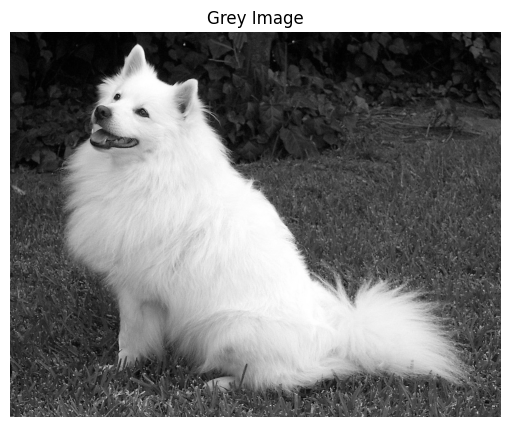

In [7]:
i_c_grey = cv2.cvtColor(i_c, cv2.COLOR_BGR2GRAY)

# Save the grayscale image
cv2.imwrite('dog_gray.png', i_c_grey)

# Display the grayscale image
plt.figure(figsize=(10, 5))
plt.subplot(1, 1, 1)
plt.imshow(i_c_grey, cmap='gray')
plt.title('Grey Image')
plt.axis('off')

plt.show()

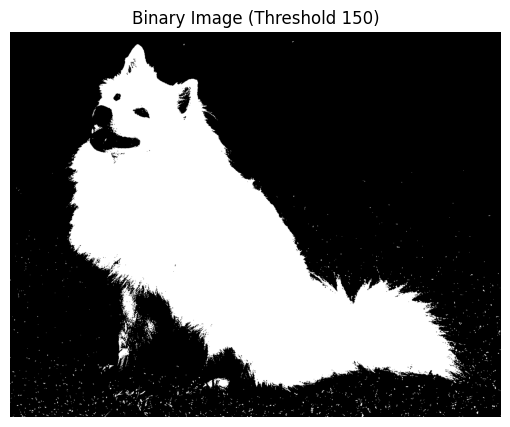

In [ ]:
# The cv2.threshold function is used incorrectly.
# It expects the source image, a threshold value, a max_value, and a thresholding type.
# Also, cv2.threshold returns two values (ret, binary_image), and the output should be assigned to i_c_binary.
# cv2.cvtColor is not needed here, as we are converting a grayscale image to binary using thresholding.

# Convert the obtained gray-scale image into a binary image using cv2.threshold() for threshold value 150.
# The 'ret' value is the actual threshold used, 'i_c_binary1' is the resulting binary image.
ret, i_c_binary1 = cv2.threshold(i_c_grey, 150, 255, cv2.THRESH_BINARY)

# Save the binary image
cv2.imwrite('dog_binary1.png', i_c_binary1)

# Display the binary image
plt.figure(figsize=(10, 5))
plt.subplot(1, 1, 1)
plt.imshow(i_c_binary1, cmap='gray') # Binary images are usually displayed in grayscale
plt.title('Binary Image (Threshold 150)')
plt.axis('off')

plt.show()

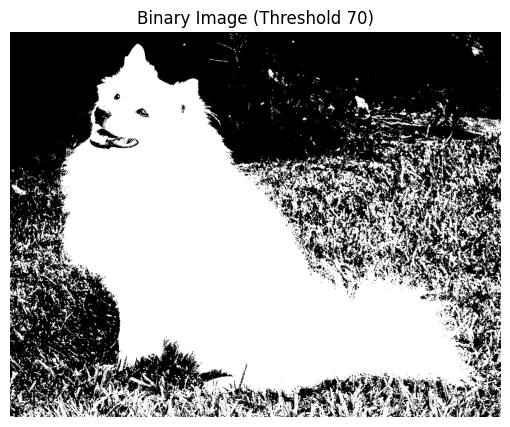

In [ ]:
ret, i_c_binary2 = cv2.threshold(i_c_grey, 70, 255, cv2.THRESH_BINARY)

# Save the binary image
cv2.imwrite('dog_binary2.png', i_c_binary1)

# Display the binary image
plt.figure(figsize=(10, 5))
plt.subplot(1, 1, 1)
plt.imshow(i_c_binary2, cmap='gray')
plt.title('Binary Image (Threshold 70)')
plt.axis('off')

plt.show()

# 2. Histogram

**Exercise 2.1  (5 points)** :
- Load image '**dog_gray.png**' into gray-scale. Compute and display its histogram by using cv.calcHist(). Please use #bin = 256.
- Find the number of pixels from histogram, whose gray-scale intensity is equal to 150.
- Select #bin = 20 and display the resulted histogram.

Reference: https://docs.opencv.org/4.x/d1/db7/tutorial_py_histogram_begins.html

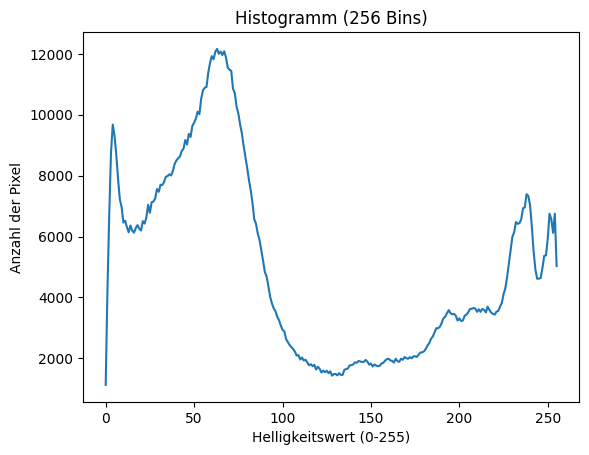

In [ ]:


dog_gray = cv2.imread('dog_gray.png', cv2.IMREAD_GRAYSCALE)
assert dog_gray is not None, "file could not be read, check with os.path.exists()"
hist_dog_gray = cv2.calcHist([dog_gray],[0],None,[256],[0,256])

# Visualisierung, just for fun
plt.plot(hist_dog_gray)
plt.title("Histogramm (256 Bins)")
plt.xlabel("Helligkeitswert (0-255)")
plt.ylabel("Anzahl der Pixel")
plt.show()



In [ ]:
pixel_count_150 = hist_dog_gray[150]

print(f"Es gibt genau {pixel_count_150[0]} Pixel mit der Intensität 150.")

Es gibt genau 1830.0 Pixel mit der Intensität 150.


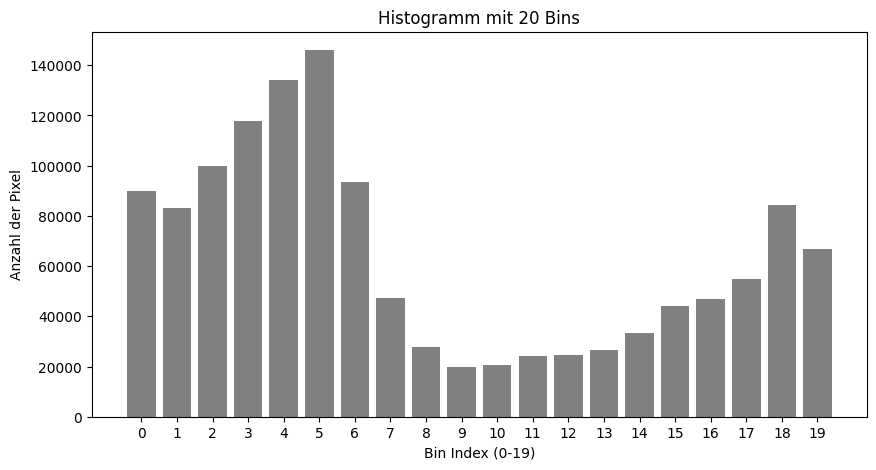

In [ ]:
# 1. Histogramm mit nur 20 Bins berechnen
# [dog_gray]: Dein Bild, [0]: Kanal, None: Keine Maske, [20]: Anzahl Bins, [0, 256]: Wertebereich
hist_20 = cv2.calcHist([dog_gray], [0], None, [20], [0, 256])

# 2. Das Ergebnis anzeigen
plt.figure(figsize=(10, 5))
# Bei wenigen Bins ist ein Balkendiagramm (bar) oft übersichtlicher als eine Linie (plot)
plt.bar(range(20), hist_20.flatten(), width=0.8, color='gray')

plt.title("Histogramm mit 20 Bins")
plt.xlabel("Bin Index (0-19)")
plt.ylabel("Anzahl der Pixel")
plt.xticks(range(20)) # Zeigt alle 20 Ticks auf der X-Achse
plt.show()

**Exercise 2.2 (5 points)**: 16-bit image

- Convert the 8-bit image '**dog_gray.png**' into an 16-bit image using numpy operations. Save it as "**dog_gray_16bit.png**" using cv2.imwrite().
- Display its histogram by #bins = 512.
- Explain why there are zeros in the histogram of the obtained 16-bit image.

Note:
a) In Windows OP, one can right-click an image file, then click property, in "Bit-depth" one can verify the number of bits per pixel.

b) Value 255 = 2^8 -1 in 8-bit image corresponds to value 2^16-1 in 16-bit images

In [ ]:
# Bild laden
img_8bit = cv2.imread('dog_gray.png', cv2.IMREAD_GRAYSCALE)

# Umrechnung: 8-bit * 257 = 16-bit
# (255 * 257 = 65535)
img_16bit = (img_8bit.astype(np.uint32) * 257).astype(np.uint16)

# Speichern
cv2.imwrite('dog_gray_16bit.png', img_16bit)

True

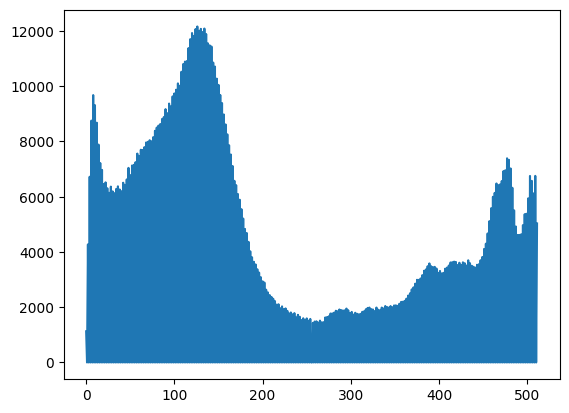

In [ ]:
hist_16 = cv2.calcHist([img_16bit], [0], None, [512], [0, 65536])
plt.plot(hist_16)
plt.show()

Weil durch die Skalierung auf eine höhere Bildqualität, weißräume entstehen, welche man durch das Histogramm erkennen kann.

Der Grund dafür ist, dass man dem Bild nicht mehr Informationen hinzufügen kann, als durch die niedrigere Skalierung schon vorhanden sind.

**Exercise 2.3 (10 points)**: Auto-contrast

Auto-contrast operation can be described by the following transformation:



- Write a python function to realize the auto-contrast operation. Apply this function to image "**dog_lowcontrast.png**". Note that $g_{high}$ and $g_{low}$ refer to the smallest value and the largest value found in the histogram of "dog_lowcontrast.png", respectively.
- Display the histogram before and after the auto-contrast operation.
- Call function cv2.convertScaleAbs() to do auto-contrast operation. Displace the resulted histogram.

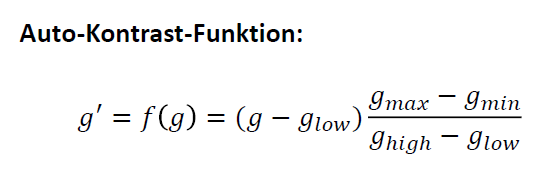

Image 'dog_lowcontrast.png' loaded successfully.


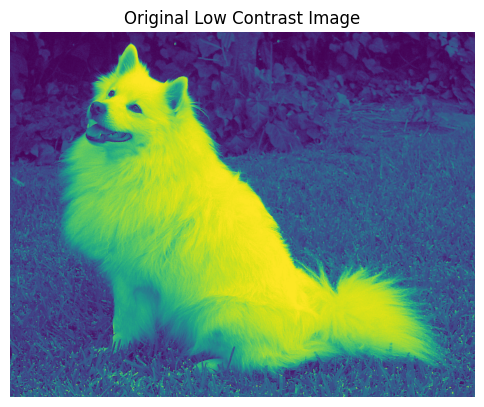

In [4]:
# Load the low contrast grayscale image
img_lowcontrast = cv2.imread('/content/ComputerVision26/Praktikum 1/dog_lowcontrast.png', cv2.IMREAD_GRAYSCALE)

# Check if the image was loaded successfully
if img_lowcontrast is None:
    print("Error: Could not load image 'dog_lowcontrast.png'. Please check the file path.")
else:
    print("Image 'dog_lowcontrast.png' loaded successfully.")
    plt.figure(figsize=(6, 6))
    plt.imshow(img_lowcontrast)
    plt.title('Original Low Contrast Image')
    plt.axis('off')
    plt.show()

In [5]:
def auto_contrast(image):
    # g_low und g_high extrahieren (kleinster und größter vorkommender Wert)
    g_low = np.min(image)
    g_high = np.max(image)

    # Sicherstellen, dass wir nicht durch Null teilen (falls das Bild einfarbig ist)
    if g_high == g_low:
        return image

    # Die Formel anwenden:
    # 1. Bild in float umwandeln für präzise Rechnung
    # 2. Skalierung durchführen
    # 3. Zurück in uint8 (8-Bit) konvertieren und auf 0-255 clippen
    img_stretched = (image.astype(np.float32) - g_low) * (255.0 / (g_high - g_low))

    return np.clip(img_stretched, 0, 255).astype(np.uint8)

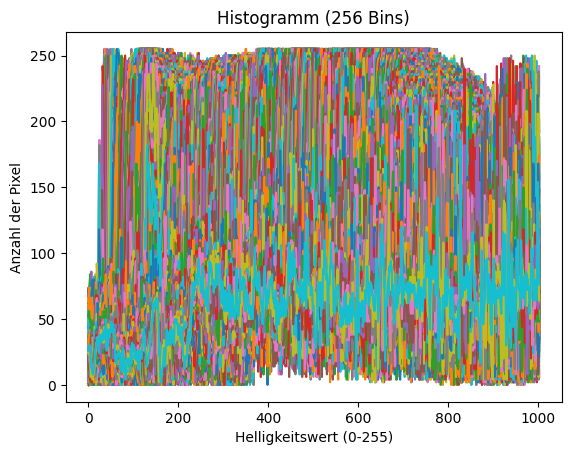

In [12]:
image_autocontrast = auto_contrast(img_lowcontrast)
hist_image_autocontrast = cv2.calcHist([image_autocontrast],[0],None,[256],[0,256])

# Visualisierung, just for fun
plt.figure()
plt.plot(image_autocontrast)
plt.title("Histogramm Autocontrast")
plt.xlabel("Helligkeitswert (0-255)")
plt.ylabel("Anzahl der Pixel")
plt.show()


**Exercise 2.4 (10 points)**:
Clipping contains two steps.
- Step 1: Select proper values of $g_{0}$ and $g_1$. Mapping all pixel values, which are smaller than $g_0$, to 0. Mapping all pixel values, which are bigger than $g_1$ to 255.
- Step 2: Auto-contrast operation for the rest pixels, which have gray-scale values $\in$ [$g_0$, $g_1$].

For 8-bit image, clipping can be formulated as the following transformation:

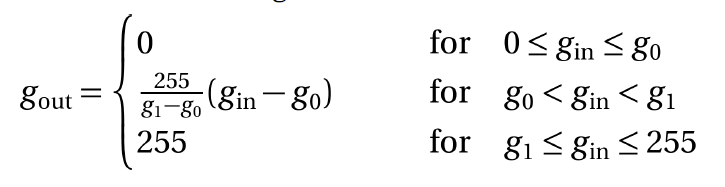


Please realize the clipping operaiton to the gray image "**dog_gray.png**". Please choose $g_0$ and $g_1$ such that 2.5% of total pixels have gray values less than $g_0$ and 2.5% of total pixels have values greater than $g_1$.

Required outputs:
*   Print the selected values of $g_0$ and $g_1$
*   Display the resulted picture after clipping and its histogram.

Selected g0: 5
Selected g1: 249


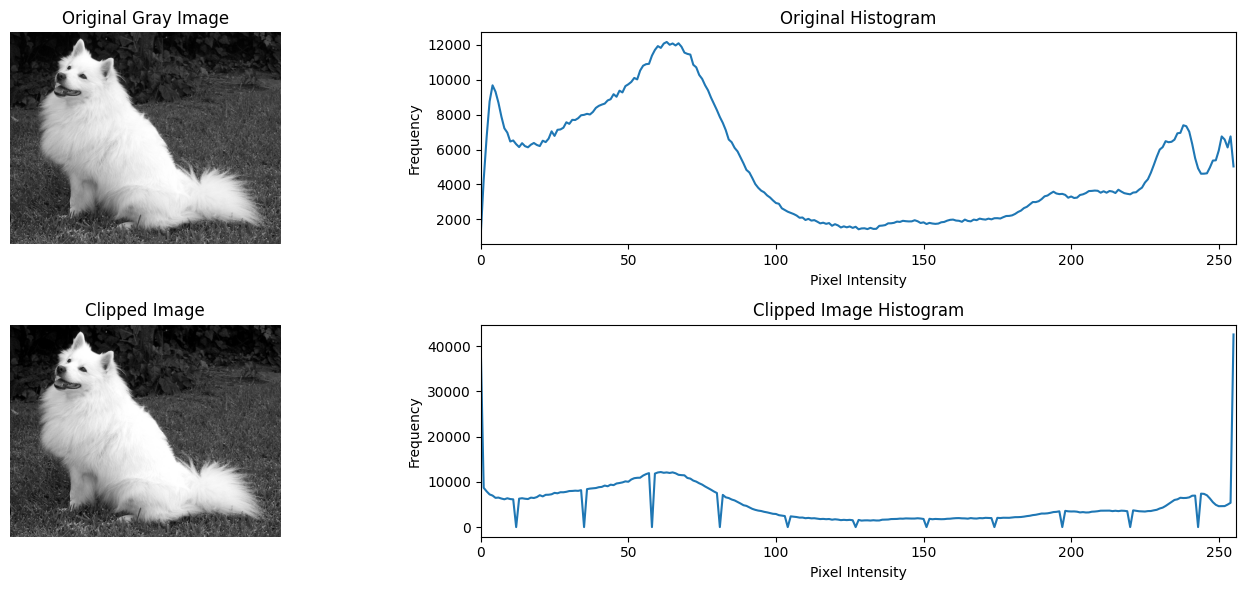

In [8]:
# Load the gray image 'dog_gray.png'
img_gray = cv2.imread('dog_gray.png', cv2.IMREAD_GRAYSCALE)

# Check if image loaded successfully
if img_gray is None:
    print("Error: Could not load image 'dog_gray.png'. Please ensure the file exists.")
else:
    # Calculate histogram
    hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256])

    # Calculate cumulative distribution function (CDF)
    cdf = hist.cumsum()
    cdf_normalized = cdf * hist.max() / cdf.max()

    # Total number of pixels
    total_pixels = img_gray.shape[0] * img_gray.shape[1]

    # Find g0 (2.5% of total pixels less than g0)
    target_pixels_low = total_pixels * 0.025
    g0 = 0
    for i in range(256):
        if cdf[i] >= target_pixels_low:
            g0 = i
            break

    # Find g1 (2.5% of total pixels greater than g1)
    target_pixels_high = total_pixels * 0.975
    g1 = 255
    for i in range(255, -1, -1):
        if cdf[i] <= target_pixels_high:
            g1 = i
            break

    print(f"Selected g0: {g0}")
    print(f"Selected g1: {g1}")

    # Apply clipping transformation
    img_clipped = np.zeros_like(img_gray, dtype=np.uint8)
    # Avoid division by zero if g1 == g0
    if (g1 - g0) == 0:
        # If g1 and g0 are the same, all values are mapped to 0 or 255 depending on threshold
        img_clipped[img_gray <= g0] = 0
        img_clipped[img_gray > g0] = 255
    else:
        img_clipped = np.where(img_gray < g0, 0,
                             np.where(img_gray > g1, 255,
                                      np.round((img_gray - g0) * (255.0 / (g1 - g0))).astype(np.uint8)))

    # Calculate histogram of the clipped image
    hist_clipped = cv2.calcHist([img_clipped], [0], None, [256], [0, 256])

    # Display images and histograms
    plt.figure(figsize=(15, 6))

    plt.subplot(2, 2, 1)
    plt.imshow(img_gray, cmap='gray')
    plt.title('Original Gray Image')
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.plot(hist)
    plt.title('Original Histogram')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.xlim([0, 256])

    plt.subplot(2, 2, 3)
    plt.imshow(img_clipped, cmap='gray')
    plt.title('Clipped Image')
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.plot(hist_clipped)
    plt.title('Clipped Image Histogram')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.xlim([0, 256])

    plt.tight_layout()
    plt.show()